# Xie-Style Compositional Regression for Stop-Signal Task

This notebook implements the compositional regression approach from Xie et al. (2022) adapted for stop-signal tasks.

## Overview
- **Slot 1 (GO direction)**: L/R (2 regressors)
- **Slot 2 (second cue)**: NONE (GO), STOP_succ/fail_SSD1-4, CONT_SSD1-4 (15 total regressors)
- Fit sparse regression (Lasso) with repeated half-splits for stability
- Build population vectors from fitted β coefficients
- PCA within groups to define subspaces
- Analyze subspace geometry (principal angles, variance overlap)

In [42]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from scipy.linalg import subspace_angles
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
import warnings
warnings.filterwarnings('ignore')

# Import project modules
import sys
sys.path.append('..')
from cell_analysis import Cell
from session_class import Session

# Import parallel processing helpers
from parallel_helpers import fit_single_cell_worker

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## Configuration

In [43]:
# Analysis configuration
config = {
    # Data parameters
    'data_path': '../../data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl',
    'session_id': 'fi211115a',  # Good multi-cell session
    
    # Time window parameters
    'epok': [0, 150],  # Analysis window relative to stop_cue (ms)
    'bin_size': 50,    # Bin size for spike counts (ms)
    
    # Regression parameters
    'n_splits': 100,   # Number of half-splits for stability
    'alpha_cv_folds': 5,  # Cross-validation folds for alpha selection
    'random_state': 42,
    
    # PCA parameters
    'n_components': 2,  # Components per subspace
    
    # Trial filtering
    'min_trials_per_condition': 5,
    'success_only': True,
    
    # Parallel processing
    'n_workers': max(1, mp.cpu_count() - 2),  # Leave 2 cores free
}

## 1. Data Loading and Preparation

In [44]:
# Load data
print("Loading data...")
cell_df = pd.read_pickle(config['data_path'])
print(f"Loaded {len(cell_df):,} cell-trial combinations")

# Filter to specific session
session_data = cell_df[cell_df['trial_session'] == config['session_id']]
print(f"\nSession {config['session_id']}:")
print(f"  - {session_data['cell_ID'].nunique()} cells")
print(f"  - {len(session_data['trial_number'].unique())} trials")

# Create session
session = Session(session_data, verbose=True)
session.drop_cells_with_missing_trial_type_or_dir_data()

print(f"\nAfter filtering: {session.n_cells} cells")

Loading data...
Loaded 770,705 cell-trial combinations

Session fi211115a:
  - 53 cells
  - 960 trials
Session fi211115a initialized:
  - Number of cells: 53
  - Total trials: 960
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]

After filtering: 53 cells


## 2. Build Design Matrix

Each trial activates exactly two regressors:
- **Slot 1**: GO_L or GO_R
- **Slot 2**: NONE, STOPsucc_SSD1-4, STOPfail_SSD1-4, or CONT_SSD1-4

In [45]:
def build_design_matrix(session_data, config):
    """
    Build two-hot design matrix for Xie-style regression.
    
    Returns:
    --------
    X : ndarray (n_trials, n_features)
        Design matrix
    feature_names : list
        Names of features/regressors
    trial_info : DataFrame
        Trial metadata for alignment
    """
    # Define feature names
    slot1_features = ['GO_L', 'GO_R']
    slot2_features = ['NONE']  # For GO trials
    
    # Add STOP features (success/fail × SSD1-4)
    for outcome in ['succ', 'fail']:
        for ssd in [1, 2, 3, 4]:
            slot2_features.append(f'STOP{outcome}_SSD{ssd}')
    
    # Add CONT features (SSD1-4)
    for ssd in [1, 2, 3, 4]:
        slot2_features.append(f'CONT_SSD{ssd}')
    
    feature_names = slot1_features + slot2_features
    n_features = len(feature_names)
    
    print(f"Design matrix: {n_features} features")
    print(f"  Slot 1 (direction): {len(slot1_features)}")
    print(f"  Slot 2 (cue type): {len(slot2_features)}")
    
    # Get unique trials
    trials = session_data.drop_duplicates(subset='trial_number').copy()
    n_trials = len(trials)
    
    # Initialize design matrix
    X = np.zeros((n_trials, n_features))
    
    # Build feature index mapping
    feature_idx = {name: i for i, name in enumerate(feature_names)}
    
    # Fill design matrix
    for i, (_, trial) in enumerate(trials.iterrows()):
        # Slot 1: Direction
        dir_feature = 'GO_L' if trial['dir'] == 180 else 'GO_R'
        X[i, feature_idx[dir_feature]] = 1
        
        # Slot 2: Trial type
        if trial['type'] == 'GO':
            X[i, feature_idx['NONE']] = 1
        elif trial['type'] == 'CONT':
            ssd_num = int(trial['ssd_number'])
            X[i, feature_idx[f'CONT_SSD{ssd_num}']] = 1
        elif trial['type'] == 'STOP':
            ssd_num = int(trial['ssd_number'])
            outcome = 'succ' if not trial['trial_failed'] else 'fail'
            X[i, feature_idx[f'STOP{outcome}_SSD{ssd_num}']] = 1
    
    # Verify each row has exactly 2 ones
    row_sums = X.sum(axis=1)
    assert np.all(row_sums == 2), f"Design matrix error: rows should sum to 2, got {np.unique(row_sums)}"
    
    print(f"✓ Design matrix built: {X.shape}")
    print(f"  Feature usage: min={X.sum(axis=0).min():.0f}, max={X.sum(axis=0).max():.0f} trials")
    
    return X, feature_names, trials

# Build design matrix
X, feature_names, trial_info = build_design_matrix(session.data, config)

Design matrix: 15 features
  Slot 1 (direction): 2
  Slot 2 (cue type): 13
✓ Design matrix built: (960, 15)
  Feature usage: min=2, max=529 trials


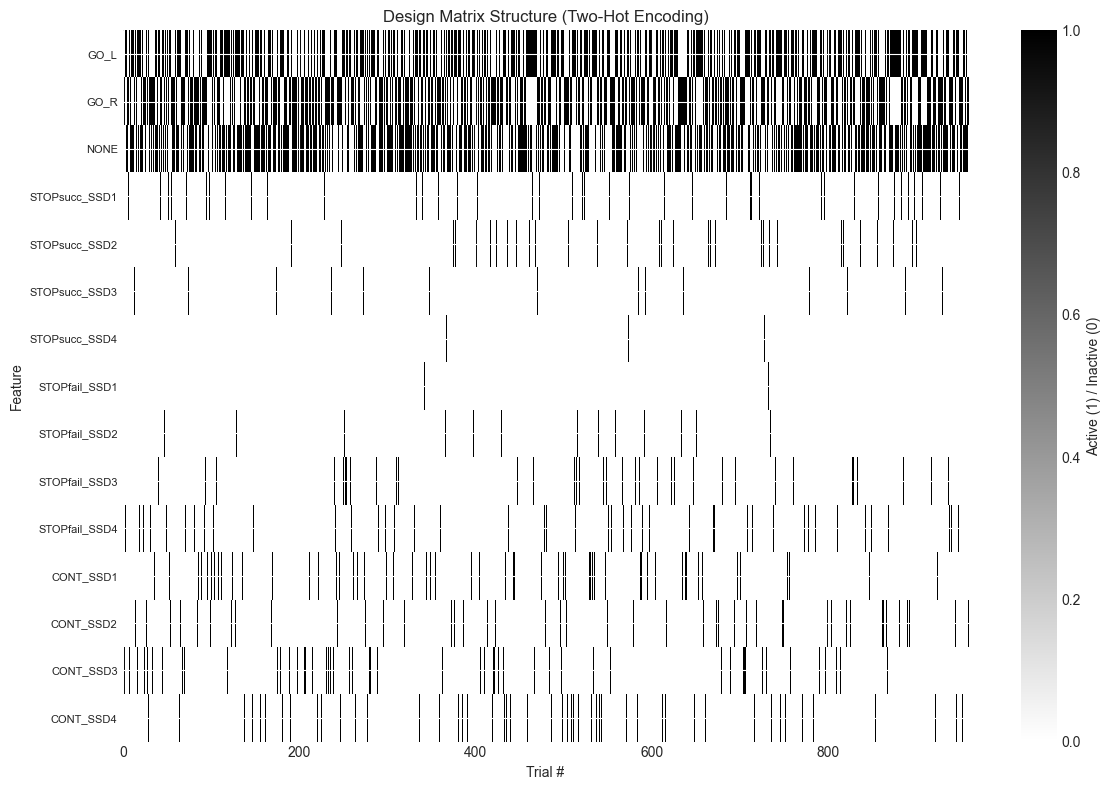

In [46]:
# Visualize design matrix structure
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(X.T, aspect='auto', cmap='binary', interpolation='nearest')
ax.set_xlabel('Trial #')
ax.set_ylabel('Feature')
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels(feature_names, fontsize=8)
ax.set_title('Design Matrix Structure (Two-Hot Encoding)')
plt.colorbar(im, ax=ax, label='Active (1) / Inactive (0)')
plt.tight_layout()
plt.show()

## 3. Extract Response Variables

For each neuron, extract spike count in the analysis window aligned to stop_cue (with pseudo-SSD for GO trials).

In [47]:
def sample_pseudo_ssd(session_data, random_state=None):
    """
    Sample pseudo-SSD for GO trials from empirical SSD distribution.
    
    Returns:
    --------
    mean_ssd : float
        Mean SSD value to use for all GO trials
    """
    # Get SSD distribution from STOP trials
    stop_trials = session_data[
        (session_data['type'] == 'STOP') & 
        (session_data['trial_failed'] == False)
    ]
    
    ssd_values = stop_trials['ssd_len'].dropna().values
    mean_ssd = np.mean(ssd_values)
    
    print(f"Pseudo-SSD for GO trials: {mean_ssd:.1f} ms (mean of STOP SSDs)")
    print(f"  Based on {len(ssd_values)} successful STOP trials")
    
    return mean_ssd

def extract_response_matrix(session, trial_info, config):
    """
    Extract spike counts for all cells in analysis window.
    Optimized with pandas indexing instead of iterrows().

    Returns:
    --------
    Y : ndarray (n_cells, n_trials)
        Response matrix with spike counts
    cell_ids : list
        Cell identifiers
    """
    # Get pseudo-SSD for GO trials
    mean_ssd = sample_pseudo_ssd(session.data, config['random_state'])

    n_trials = len(trial_info)
    n_cells = session.n_cells
    Y = np.zeros((n_cells, n_trials))
    cell_ids = session.cell_ids

    print(f"\nExtracting responses for {n_cells} cells × {n_trials} trials...")

    # Pre-extract trial info as numpy arrays for fast access
    trial_numbers = trial_info['trial_number'].values
    trial_types = trial_info['type'].values

    for cell_idx, cell_id in enumerate(tqdm(cell_ids, desc="Cells")):
        cell = session.get_cell(cell_id)

        # Set index on cell data for O(1) lookup instead of O(n) filtering
        cell_data_indexed = cell.data.set_index('trial_number')

        # For each trial, compute spike count in window
        for trial_idx in range(n_trials):
            trial_num = trial_numbers[trial_idx]
            trial_type = trial_types[trial_idx]

            # Fast indexed lookup instead of filtering
            if trial_num not in cell_data_indexed.index:
                continue

            cell_trial = cell_data_indexed.loc[trial_num]

            # Determine cue2 time (stop_cue or pseudo for GO)
            if trial_type == 'GO':
                t_cue2 = cell_trial['go_cue'] + mean_ssd
            else:
                t_cue2 = cell_trial['stop_cue']

            # Extract spikes in window
            spikes = np.array(cell_trial['neural_data'])
            t_start = t_cue2 + config['epok'][0]
            t_end = t_cue2 + config['epok'][1]

            spike_count = np.sum((spikes >= t_start) & (spikes < t_end))
            Y[cell_idx, trial_idx] = spike_count

    print(f"✓ Response matrix: {Y.shape}")
    print(f"  Mean spike count: {Y.mean():.2f} ± {Y.std():.2f}")
    print(f"  Range: [{Y.min():.0f}, {Y.max():.0f}]")

    return Y, cell_ids

# Extract responses
Y, cell_ids = extract_response_matrix(session, trial_info, config)

Pseudo-SSD for GO trials: 93.6 ms (mean of STOP SSDs)
  Based on 3762 successful STOP trials

Extracting responses for 53 cells × 960 trials...


Cells: 100%|██████████| 53/53 [00:02<00:00, 19.84it/s]

✓ Response matrix: (53, 960)
  Mean spike count: 0.85 ± 1.71
  Range: [0, 20]


## 4. Fit Sparse Regression with Half-Split Stability

Following Xie et al., fit Lasso regression with:
- Repeated random half-splits (100 iterations)
- Cross-validation for α selection on each half
- Average coefficients across all splits
- **Parallel processing** using `ProcessPoolExecutor` with tqdm progress bars

**Performance**: On an 8-core machine, parallel processing is ~6x faster than sequential fitting.

In [48]:
def fit_all_cells_parallel(X, Y, feature_names, config):
    """
    Fit regression for all cells using parallel processing with ProcessPoolExecutor.
    
    Returns:
    --------
    betas : ndarray (n_cells, n_features)
        Fitted coefficients
    betas_std : ndarray (n_cells, n_features)
        Standard deviations of coefficients
    """
    n_cells, n_trials = Y.shape
    n_features = X.shape[1]
    
    betas = np.zeros((n_cells, n_features))
    betas_std = np.zeros((n_cells, n_features))
    
    n_workers = config.get('n_workers', max(1, mp.cpu_count() - 2))
    
    print(f"\nFitting Lasso regression for {n_cells} cells...")
    print(f"  {config['n_splits']} half-splits per cell")
    print(f"  {config['alpha_cv_folds']}-fold CV for alpha selection")
    print(f"  Using {n_workers} parallel workers (ProcessPoolExecutor)")
    print("-" * 80)
    
    # Prepare arguments for all cells
    args_list = [
        (cell_idx, Y[cell_idx, :], X, config['n_splits'], 
         config['alpha_cv_folds'], config['random_state'])
        for cell_idx in range(n_cells)
    ]
    
    # Process in parallel with ProcessPoolExecutor
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        # Submit all jobs
        futures = {executor.submit(fit_single_cell_worker, args): args[0] 
                   for args in args_list}
        
        # Collect results with progress bar
        for future in tqdm(as_completed(futures), total=n_cells, desc="Fitting"):
            cell_idx, beta_mean, beta_std = future.result()
            betas[cell_idx, :] = beta_mean
            betas_std[cell_idx, :] = beta_std
    
    print(f"\n✓ Regression complete")
    print(f"  Non-zero coefficients: {(np.abs(betas) > 1e-6).sum()} / {betas.size}")
    print(f"  Sparsity: {100 * (np.abs(betas) < 1e-6).sum() / betas.size:.1f}%")
    
    return betas, betas_std


# Fit all cells in parallel
betas, betas_std = fit_all_cells_parallel(X, Y, feature_names, config)


Fitting Lasso regression for 53 cells...
  100 half-splits per cell
  5-fold CV for alpha selection
  Using 6 parallel workers (ProcessPoolExecutor)
--------------------------------------------------------------------------------


Fitting:  79%|███████▉  | 42/53 [01:19<00:10,  1.04it/s]/Users/barak/Projects/population_analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/barak/Projects/population_analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/barak/Projects/population_analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did


✓ Regression complete
  Non-zero coefficients: 688 / 795
  Sparsity: 13.5%


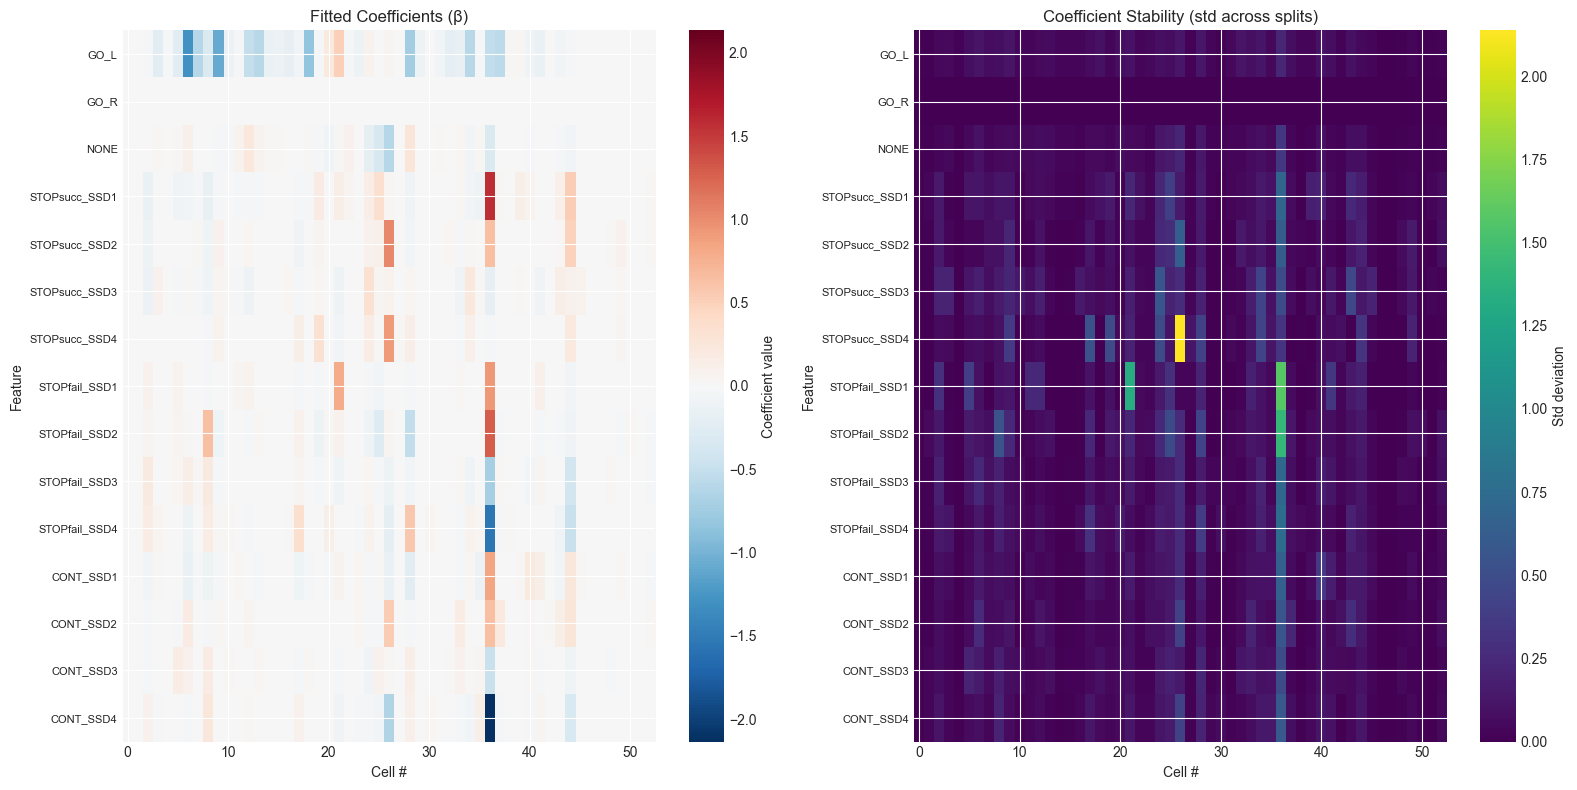

In [49]:
# Visualize coefficient matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Mean coefficients
im1 = axes[0].imshow(betas.T, aspect='auto', cmap='RdBu_r', 
                     vmin=-np.abs(betas).max(), vmax=np.abs(betas).max())
axes[0].set_xlabel('Cell #')
axes[0].set_ylabel('Feature')
axes[0].set_yticks(range(len(feature_names)))
axes[0].set_yticklabels(feature_names, fontsize=8)
axes[0].set_title('Fitted Coefficients (β)')
plt.colorbar(im1, ax=axes[0], label='Coefficient value')

# Standard deviations
im2 = axes[1].imshow(betas_std.T, aspect='auto', cmap='viridis')
axes[1].set_xlabel('Cell #')
axes[1].set_ylabel('Feature')
axes[1].set_yticks(range(len(feature_names)))
axes[1].set_yticklabels(feature_names, fontsize=8)
axes[1].set_title('Coefficient Stability (std across splits)')
plt.colorbar(im2, ax=axes[1], label='Std deviation')

plt.tight_layout()
plt.show()

## 5. Build Population Vectors

Each feature defines a population vector across all cells:
$$v(\text{feature}) = [\beta_1(\text{feature}), \ldots, \beta_N(\text{feature})]^\top$$

In [50]:
def build_population_vectors(betas, feature_names):
    """
    Build population vectors from fitted coefficients.
    
    Returns:
    --------
    pop_vectors : dict
        Dictionary mapping feature names to population vectors (n_cells,)
    """
    pop_vectors = {}
    
    for feat_idx, feat_name in enumerate(feature_names):
        pop_vectors[feat_name] = betas[:, feat_idx]
    
    print(f"✓ Built {len(pop_vectors)} population vectors")
    print(f"  Each vector has {betas.shape[0]} dimensions (cells)")
    
    return pop_vectors

pop_vectors = build_population_vectors(betas, feature_names)

✓ Built 15 population vectors
  Each vector has 53 dimensions (cells)


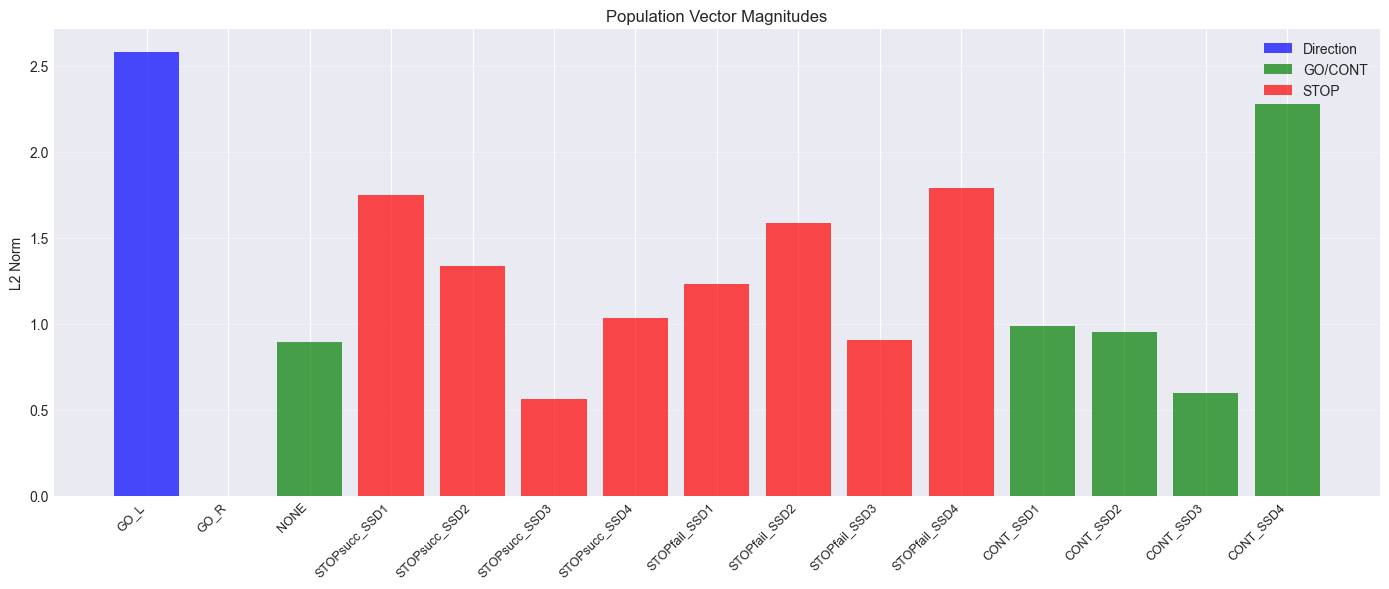

In [51]:
# Analyze population vector norms
vector_norms = {name: np.linalg.norm(vec) for name, vec in pop_vectors.items()}

fig, ax = plt.subplots(figsize=(14, 6))
names = list(vector_norms.keys())
norms = list(vector_norms.values())
colors = ['blue' if 'GO' in n else 'red' if 'STOP' in n else 'green' for n in names]

bars = ax.bar(range(len(names)), norms, color=colors, alpha=0.7)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('L2 Norm')
ax.set_title('Population Vector Magnitudes')
ax.grid(axis='y', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', alpha=0.7, label='Direction'),
    Patch(facecolor='green', alpha=0.7, label='GO/CONT'),
    Patch(facecolor='red', alpha=0.7, label='STOP')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## 6. PCA Within Groups → Define Subspaces

Group related population vectors and perform PCA to define low-dimensional subspaces:
- **STOP Success**: {STOPsucc_SSD1-4} → stopping subspace
- **STOP Fail**: {STOPfail_SSD1-4} → failed-stop subspace
- **CONT**: {CONT_SSD1-4} → continue subspace

In [60]:
def define_subspaces(pop_vectors, n_components=2):
    """
    Group population vectors and perform PCA to define subspaces.
    
    Returns:
    --------
    subspaces : dict
        Dictionary with keys 'stop_succ', 'stop_fail', 'cont'
        Values are dicts with 'basis' (n_cells × n_components) and 'pca' object
    """
    subspaces = {}
    
    # Group 1: STOP Success
    stop_succ_keys = [k for k in pop_vectors.keys() if 'STOPsucc' in k]
    stop_succ_matrix = np.stack([pop_vectors[k] for k in stop_succ_keys], axis=0)  # (4, n_cells)
    
    # De-mean before PCA
    stop_succ_matrix_dm = stop_succ_matrix - stop_succ_matrix.mean(axis=0, keepdims=True)
    pca_succ = PCA(n_components=n_components)
    pca_succ.fit(stop_succ_matrix_dm)
    subspaces['stop_succ'] = {
        'basis': pca_succ.components_.T,  # (n_cells, n_components)
        'pca': pca_succ,
        'vectors': stop_succ_keys
    }
    
    # Group 2: STOP Fail
    stop_fail_keys = [k for k in pop_vectors.keys() if 'STOPfail' in k]
    stop_fail_matrix = np.stack([pop_vectors[k] for k in stop_fail_keys], axis=0)
    
    stop_fail_matrix_dm = stop_fail_matrix - stop_fail_matrix.mean(axis=0, keepdims=True)
    pca_fail = PCA(n_components=n_components)
    pca_fail.fit(stop_fail_matrix_dm)
    subspaces['stop_fail'] = {
        'basis': pca_fail.components_.T,
        'pca': pca_fail,
        'vectors': stop_fail_keys
    }
    
    # Group 3: CONT
    cont_keys = [k for k in pop_vectors.keys() if 'CONT' in k]
    cont_matrix = np.stack([pop_vectors[k] for k in cont_keys], axis=0)
    
    cont_matrix_dm = cont_matrix - cont_matrix.mean(axis=0, keepdims=True)
    pca_cont = PCA(n_components=n_components)
    pca_cont.fit(cont_matrix_dm)
    subspaces['cont'] = {
        'basis': pca_cont.components_.T,
        'pca': pca_cont,
        'vectors': cont_keys
    }
    
    # Summary
    print("✓ Subspaces defined:")
    for name, data in subspaces.items():
        variance = data['pca'].explained_variance_ratio_
        print(f"  {name:12s}: {len(data['vectors'])} vectors → {n_components}D subspace")
        print(f"              Variance explained: {variance.sum()*100:.1f}% (PC1={variance[0]*100:.1f}%, PC2={variance[1]*100:.1f}%)")
    
    return subspaces

subspaces = define_subspaces(pop_vectors, n_components=config['n_components'])

✓ Subspaces defined:
  stop_succ   : 4 vectors → 2D subspace
              Variance explained: 96.9% (PC1=70.9%, PC2=26.0%)
  stop_fail   : 4 vectors → 2D subspace
              Variance explained: 97.8% (PC1=88.3%, PC2=9.5%)
  cont        : 4 vectors → 2D subspace
              Variance explained: 98.9% (PC1=92.2%, PC2=6.7%)


## 7. Subspace Geometry Analysis

Quantify relationships between subspaces using principal angles.

In [61]:
def compute_principal_angles(subspace_A, subspace_B):
    """
    Compute principal angles between two subspaces.
    
    Parameters:
    -----------
    subspace_A, subspace_B : ndarray (n_dims, n_components)
        Orthonormal basis matrices
    
    Returns:
    --------
    angles : ndarray
        Principal angles in degrees
    """
    angles_rad = subspace_angles(subspace_A, subspace_B)
    angles_deg = np.rad2deg(angles_rad)
    return angles_deg

def analyze_subspace_geometry(subspaces):
    """
    Compute all pairwise principal angles.
    
    Returns:
    --------
    angle_matrix : DataFrame
        Matrix of principal angles (first angle only)
    """
    names = list(subspaces.keys())
    n = len(names)
    
    angle_matrix = np.zeros((n, n))
    
    print("\nPrincipal Angles Between Subspaces:")
    print("=" * 60)
    
    for i, name_A in enumerate(names):
        for j, name_B in enumerate(names):
            if i >= j:
                continue
            
            basis_A = subspaces[name_A]['basis']
            basis_B = subspaces[name_B]['basis']
            
            angles = compute_principal_angles(basis_A, basis_B)
            angle_matrix[i, j] = angles[0]  # First principal angle
            angle_matrix[j, i] = angles[0]  # Symmetric
            
            print(f"  {name_A:12s} ↔ {name_B:12s}: {angles[0]:.1f}° (first), {angles[1]:.1f}° (second)")
    
    print("=" * 60)
    print("\nInterpretation:")
    print("  0° = subspaces are aligned (overlapping)")
    print("  90° = subspaces are orthogonal (independent)")
    
    angle_df = pd.DataFrame(angle_matrix, index=names, columns=names)
    return angle_df

angle_matrix = analyze_subspace_geometry(subspaces)


Principal Angles Between Subspaces:
  stop_succ    ↔ stop_fail   : 87.8° (first), 20.3° (second)
  stop_succ    ↔ cont        : 42.5° (first), 18.6° (second)
  stop_fail    ↔ cont        : 86.5° (first), 18.1° (second)

Interpretation:
  0° = subspaces are aligned (overlapping)
  90° = subspaces are orthogonal (independent)


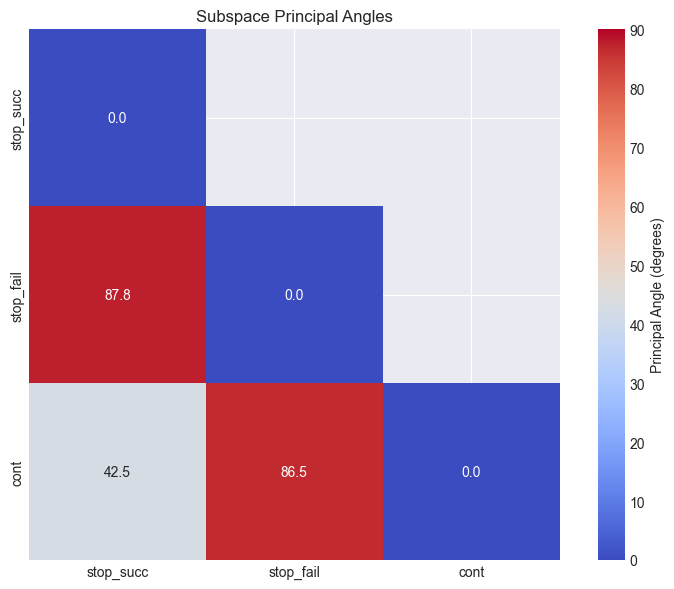

In [62]:
# Visualize angle matrix
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(angle_matrix, dtype=bool), k=1)  # Mask upper triangle
sns.heatmap(angle_matrix, annot=True, fmt='.1f', cmap='coolwarm', 
            center=45, vmin=0, vmax=90, square=True, mask=mask,
            cbar_kws={'label': 'Principal Angle (degrees)'}, ax=ax)
ax.set_title('Subspace Principal Angles')
plt.tight_layout()
plt.show()

## 8. Visualize Subspaces

Project population vectors onto 2D subspace bases.

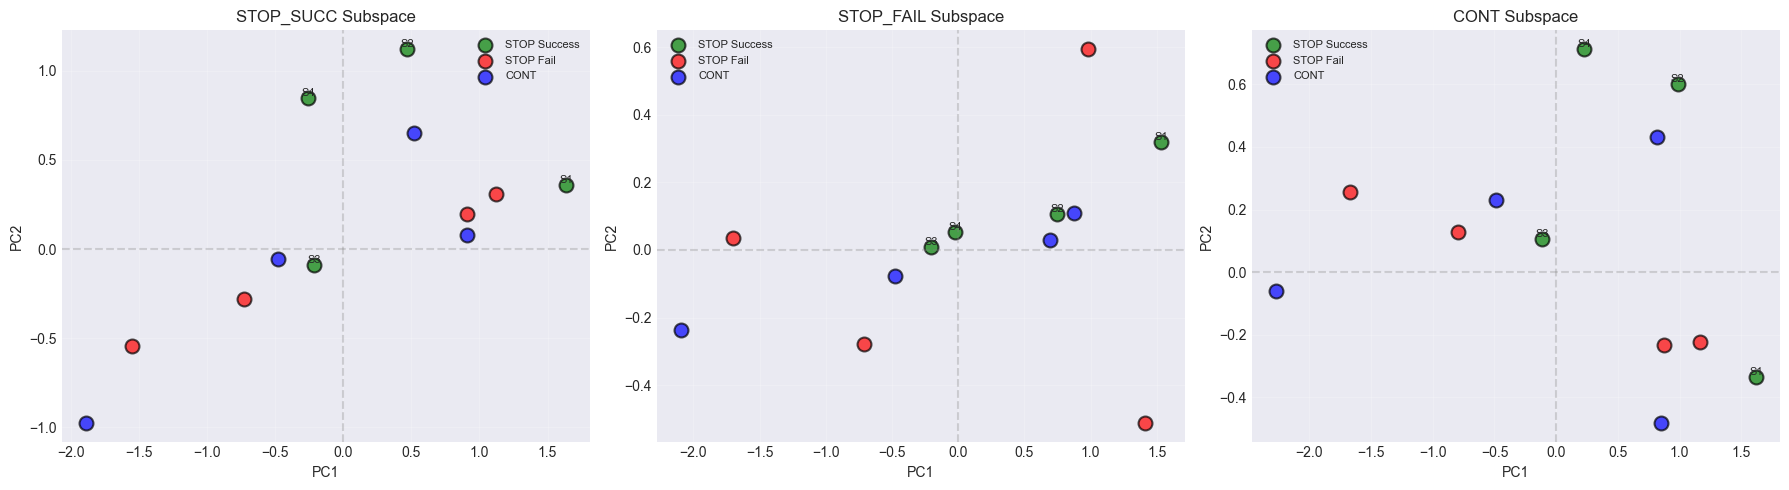

In [63]:
def project_vectors_to_subspace(pop_vectors, keys, basis):
    """
    Project population vectors onto a subspace basis.
    
    Parameters:
    -----------
    pop_vectors : dict
        Population vectors
    keys : list
        Keys to project
    basis : ndarray (n_cells, n_components)
        Subspace basis
    
    Returns:
    --------
    projections : ndarray (n_vectors, n_components)
    """
    vectors = np.stack([pop_vectors[k] for k in keys], axis=0)  # (n_vectors, n_cells)
    projections = vectors @ basis  # (n_vectors, n_components)
    return projections

# Project all vectors onto each subspace
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (subspace_name, subspace_data) in zip(axes, subspaces.items()):
    basis = subspace_data['basis']
    
    # Project STOP success vectors
    stop_succ_keys = [k for k in pop_vectors.keys() if 'STOPsucc' in k]
    proj_succ = project_vectors_to_subspace(pop_vectors, stop_succ_keys, basis)
    
    # Project STOP fail vectors
    stop_fail_keys = [k for k in pop_vectors.keys() if 'STOPfail' in k]
    proj_fail = project_vectors_to_subspace(pop_vectors, stop_fail_keys, basis)
    
    # Project CONT vectors
    cont_keys = [k for k in pop_vectors.keys() if 'CONT' in k]
    proj_cont = project_vectors_to_subspace(pop_vectors, cont_keys, basis)
    
    # Plot
    ax.scatter(proj_succ[:, 0], proj_succ[:, 1], c='green', s=100, alpha=0.7, 
              label='STOP Success', edgecolors='black', linewidths=1.5)
    ax.scatter(proj_fail[:, 0], proj_fail[:, 1], c='red', s=100, alpha=0.7,
              label='STOP Fail', edgecolors='black', linewidths=1.5)
    ax.scatter(proj_cont[:, 0], proj_cont[:, 1], c='blue', s=100, alpha=0.7,
              label='CONT', edgecolors='black', linewidths=1.5)
    
    # Add SSD labels
    for i, key in enumerate(stop_succ_keys):
        ssd = key.split('SSD')[1]
        ax.annotate(f'S{ssd}', (proj_succ[i, 0], proj_succ[i, 1]), 
                   fontsize=8, ha='center', va='bottom')
    
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'{subspace_name.upper()} Subspace')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 8b. GO Direction Subspace Analysis

Define a 2D subspace from GO direction vectors (GO_L, GO_R) and project all task conditions onto it.

✓ GO Direction subspace defined:
  Variance explained: 100.0%
  PC1: 100.0%
  PC2: 0.0%


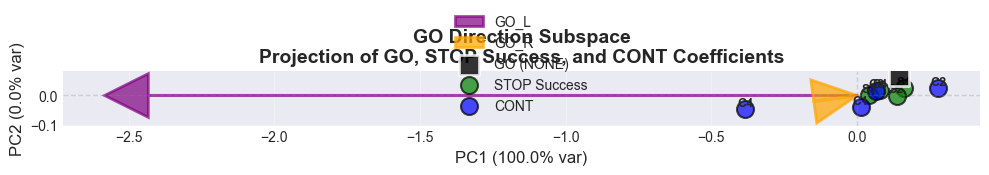


Projections onto GO Direction Subspace:
GO (NONE):        PC1=0.144, PC2=0.068
STOP Success mean: PC1=0.104, PC2=0.011
CONT mean:         PC1=-0.007, PC2=-0.012


In [64]:
# Define GO direction subspace
go_keys = ['GO_L', 'GO_R']
go_matrix = np.stack([pop_vectors[k] for k in go_keys], axis=0)  # (2, n_cells)

# De-mean before PCA
go_matrix_dm = go_matrix - go_matrix.mean(axis=0, keepdims=True)
pca_go = PCA(n_components=2)
pca_go.fit(go_matrix_dm)
go_subspace_basis = pca_go.components_.T  # (n_cells, 2)

print("✓ GO Direction subspace defined:")
print(f"  Variance explained: {pca_go.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  PC1: {pca_go.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca_go.explained_variance_ratio_[1]*100:.1f}%")

# Project vectors onto GO subspace
# GO trials (NONE feature)
go_trial_keys = ['NONE']
proj_go = project_vectors_to_subspace(pop_vectors, go_trial_keys, go_subspace_basis)

# STOP Success trials
stop_succ_keys = [k for k in pop_vectors.keys() if 'STOPsucc' in k]
proj_stop_succ = project_vectors_to_subspace(pop_vectors, stop_succ_keys, go_subspace_basis)

# CONT trials
cont_keys = [k for k in pop_vectors.keys() if 'CONT' in k]
proj_cont = project_vectors_to_subspace(pop_vectors, cont_keys, go_subspace_basis)

# Also project the GO direction vectors themselves
proj_go_dirs = project_vectors_to_subspace(pop_vectors, go_keys, go_subspace_basis)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot GO direction vectors as arrows from origin
for i, go_key in enumerate(go_keys):
    color = 'purple' if 'GO_L' in go_key else 'orange'
    label = go_key
    ax.arrow(0, 0, proj_go_dirs[i, 0], proj_go_dirs[i, 1], 
             head_width=0.15, head_length=0.15, fc=color, ec=color,
             linewidth=2, alpha=0.7, label=label, length_includes_head=True)

# Plot GO trials (NONE)
ax.scatter(proj_go[0, 0], proj_go[0, 1], c='black', s=200, alpha=0.8,
          marker='s', edgecolors='white', linewidths=2, label='GO (NONE)', zorder=5)

# Plot STOP Success trials
ax.scatter(proj_stop_succ[:, 0], proj_stop_succ[:, 1], c='green', s=150, alpha=0.7,
          label='STOP Success', edgecolors='black', linewidths=1.5)

# Plot CONT trials
ax.scatter(proj_cont[:, 0], proj_cont[:, 1], c='blue', s=150, alpha=0.7,
          label='CONT', edgecolors='black', linewidths=1.5)

# Add SSD labels for STOP success
for i, key in enumerate(stop_succ_keys):
    ssd = key.split('SSD')[1]
    ax.annotate(f'S{ssd}', (proj_stop_succ[i, 0], proj_stop_succ[i, 1]),
               fontsize=9, ha='center', va='bottom', fontweight='bold')

# Add SSD labels for CONT
for i, key in enumerate(cont_keys):
    ssd = key.split('SSD')[1]
    ax.annotate(f'C{ssd}', (proj_cont[i, 0], proj_cont[i, 1]),
               fontsize=9, ha='center', va='bottom', fontweight='bold')

# Formatting
ax.axhline(0, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axvline(0, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.set_xlabel(f'PC1 ({pca_go.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_go.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=12)
ax.set_title('GO Direction Subspace\nProjection of GO, STOP Success, and CONT Coefficients', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='best', framealpha=0.9)
ax.grid(alpha=0.3)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# Print projection statistics
print("\n" + "=" * 60)
print("Projections onto GO Direction Subspace:")
print("=" * 60)
print(f"GO (NONE):        PC1={proj_go[0, 0]:.3f}, PC2={proj_go[0, 1]:.3f}")
print(f"STOP Success mean: PC1={proj_stop_succ[:, 0].mean():.3f}, PC2={proj_stop_succ[:, 1].mean():.3f}")
print(f"CONT mean:         PC1={proj_cont[:, 0].mean():.3f}, PC2={proj_cont[:, 1].mean():.3f}")
print("=" * 60)

## 9. Summary Statistics

In [65]:
print("=" * 80)
print("XIE-STYLE ANALYSIS SUMMARY")
print("=" * 80)
print(f"\nSession: {config['session_id']}")
print(f"Cells analyzed: {len(cell_ids)}")
print(f"Trials: {len(trial_info)}")
print(f"\nRegression:")
print(f"  Features: {len(feature_names)} (2 direction + {len(feature_names)-2} cue types)")
print(f"  Half-splits: {config['n_splits']}")
print(f"  Sparsity: {100 * (np.abs(betas) < 1e-6).sum() / betas.size:.1f}%")
print(f"\nSubspaces (PC1+PC2 variance):")
for name, data in subspaces.items():
    var = data['pca'].explained_variance_ratio_.sum() * 100
    print(f"  {name:12s}: {var:.1f}%")
print(f"\nPrincipal Angles (first angle):")
print(f"  STOP Success ↔ STOP Fail: {angle_matrix.loc['stop_succ', 'stop_fail']:.1f}°")
print(f"  STOP Success ↔ CONT:      {angle_matrix.loc['stop_succ', 'cont']:.1f}°")
print(f"  STOP Fail    ↔ CONT:      {angle_matrix.loc['stop_fail', 'cont']:.1f}°")
print("=" * 80)

XIE-STYLE ANALYSIS SUMMARY

Session: fi211115a
Cells analyzed: 53
Trials: 960

Regression:
  Features: 15 (2 direction + 13 cue types)
  Half-splits: 100
  Sparsity: 13.5%

Subspaces (PC1+PC2 variance):
  stop_succ   : 96.9%
  stop_fail   : 97.8%
  cont        : 98.9%

Principal Angles (first angle):
  STOP Success ↔ STOP Fail: 87.8°
  STOP Success ↔ CONT:      42.5°
  STOP Fail    ↔ CONT:      86.5°


## 10. Save Results

In [66]:
# Save results
output_dir = Path('../../data/xie_style_results')
output_dir.mkdir(parents=True, exist_ok=True)

# Save coefficients
np.save(output_dir / f"{config['session_id']}_betas.npy", betas)
np.save(output_dir / f"{config['session_id']}_betas_std.npy", betas_std)

# Save subspace bases
for name, data in subspaces.items():
    np.save(output_dir / f"{config['session_id']}_subspace_{name}.npy", data['basis'])

# Save angle matrix
angle_matrix.to_csv(output_dir / f"{config['session_id']}_angles.csv")

# Save metadata
metadata = {
    'session_id': config['session_id'],
    'n_cells': len(cell_ids),
    'n_trials': len(trial_info),
    'n_features': len(feature_names),
    'feature_names': feature_names,
    'config': config
}

import json
with open(output_dir / f"{config['session_id']}_metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Results saved to: {output_dir}")

✓ Results saved to: ../../data/xie_style_results
